# Remaining Useful Life Prediction
### Remaining useful life (RUL) prediction estimates how many operational cycles remain before a machine fails. This is central to predictive maintenance—scheduling repairs before failure occurs rather than reacting to breakdowns or replacing components on fixed schedules. The challenge lies in learning degradation patterns from multivariate sensor data where failure modes are complex and equipment operates under varying conditions
### The NASA Turbofan Engine Degradation Simulation Dataset (C-MAPSS) contains run-to-failure data from turbofan engines. The dataset includes four subsets (FD001, FD002, FD003, FD004) with increasing complexity based on operating conditions and failure modes. Each engine runs until failure in the training set, providing complete degradation trajectories. The test set provides partial trajectories and you must predict RUL at the final observed timestep.

## Suggested Approach

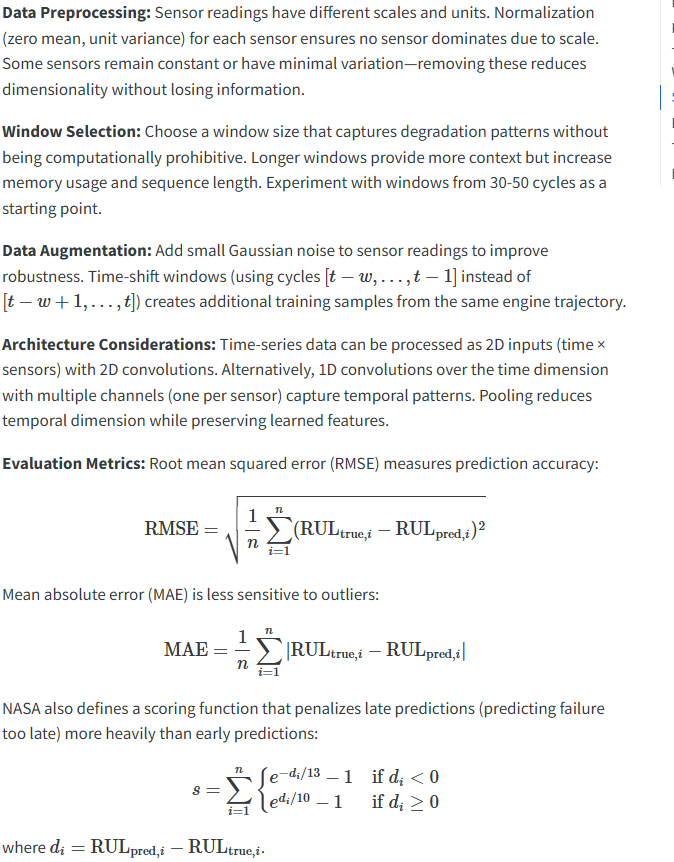

In [255]:
from IPython.display import Image, display
display(Image(filename="img1.png"))

In [256]:
# importing libraries 
import os, math, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [257]:
# fixed randomness for reproducible runs
seed = 42  # random
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
torch.backends.cudnn.benchmark = True


dev = torch.device("cuda" if torch.cuda.is_available() else "cpu") # device

In [258]:
# project configuration
data_dir = "./Data" # folder with NASA files
fd_id = "FD001"   # dataset split to use
w_size = 120     # window size (cycles) 50, 
b_size = 64    # batch size 128,
lr = 1e-3       # learning rate
wd = 1e-4       # weight decay
ep = 30         # number of epochs 50
loss_type = "huber"  # loss_type  # 'huber' or 'mse'
noise_sigma = 0.05  # gaussian augment scale

print(os.getcwd())
print ("")
print(os.listdir("./Data"))

# 3 operating settings + 21 sensors (we drop constant sensors later)
cols_keep = list(range(3, 26))  # keep columns in this range 

C:\Users\AORUS\anaconda3\envs\work\Deep Learning\Final proy

['Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']


In [259]:
# loads datset 
def load_fd_split(data_dir: str, fd_id: str):
    """
    loads train/test and RUL files for a given fd subset
   # Input:  data_dir and fd_id 'FD001' ...
   # Output: train_raw [Ntrain, 26], test_raw [Ntest, 26], rul_true [Neng_test]
""" 
    tr_path = os.path.join(data_dir, f"train_{fd_id}.txt")
    te_path = os.path.join(data_dir, f"test_{fd_id}.txt")
    ru_path = os.path.join(data_dir, f"RUL_{fd_id}.txt")

    # space-separated
    train_raw = np.loadtxt(tr_path)
    test_raw  = np.loadtxt(te_path)
    rul_true  = np.loadtxt(ru_path).reshape(-1)  # only one RUL per test engine
    
    return train_raw, test_raw, rul_true

train_raw, test_raw, rul_true = load_fd_split(data_dir, fd_id)


# feature  extraction and normalization
# raw columns: [0:id, 1:cycle, 2:setting1, 3:setting2, ..., sensors...]

idx_id, idx_t = 0, 1
feat_idx = np.array(cols_keep) - 1  # convert to 0 based

# extracts features only
X_tr_full = train_raw[:, feat_idx]   # features for train
X_te_full = test_raw[:,  feat_idx]  # features for test
eng_tr = train_raw[:, idx_id].astype(int)
eng_te = test_raw[:,  idx_id].astype(int)
t_tr = train_raw[:, idx_t].astype(int)
t_te = test_raw[:,  idx_t].astype(int)

# drops constant sensors (zero variance)
var_tr = X_tr_full.var(axis=0)
keep_mask = var_tr > 1e-6
X_tr_full = X_tr_full[:, keep_mask]
X_te_full = X_te_full[:, keep_mask]
feat_names_kept = np.arange(feat_idx.size)[keep_mask]
n_feat = X_tr_full.shape[1]  # number of kept features

# normalize using traning stats only
mu = X_tr_full.mean(axis=0)    # mean per feature
sd = X_tr_full.std(axis=0) + 1e-8   # std per feature
X_tr_full = (X_tr_full - mu) / sd
X_te_full = (X_te_full - mu) / sd

# re-attach engine id + cycle columns 
train_rec = np.concatenate([train_raw[:, [idx_id, idx_t]], X_tr_full], axis=1)  # [id, t, feats...]
test_rec  = np.concatenate([test_raw[:,  [idx_id, idx_t]], X_te_full], axis=1)

In [260]:
# compute RUL for training rows

def compute_train_rul(rec: np.ndarray):
    """
    Computes Remaining Useful Life (RUL) for each row of the TRAIN set
    for every engine: RUL = (last cycle) - (current cycle)
   """
   
    eng = rec[:, 0].astype(int)
    t   = rec[:, 1].astype(int)
    rul = np.zeros_like(t)
    
    for e in np.unique(eng):
        m = (eng == e)
        t_e = t[m]
        t_last = t_e.max()
        rul[m] = t_last - t_e
        
    return rul

# extracts last rows for TEST set
def compute_test_last_windows(rec: np.ndarray, rul_true: np.ndarray):
    """
    For test set:
    1 extract one final row per engine
    2 return those rows + their true RUL
    3 this is the window to make predictions on
    """ 
    
    eng = rec[:, 0].astype(int)
    t   = rec[:, 1].astype(int)
    engines = np.unique(eng)
    rows_last = []
    
    for i, e in enumerate(engines):
        m = eng == e
        idx = np.argmax(t[m]) #  last cycle idx
        rows_last.append(rec[m][idx])
    y_true = rul_true.copy()
    
    return rows_last, y_true

y_tr_full = compute_train_rul(train_rec)  # per row RUL in train

In [261]:
# sliding window
def windows_from_engine(mat_e: np.ndarray, w: int):
    
    """
    create all sliding windows for a single engine where
    each window has length 'w' and the label is the RUL at the last cycle
    """
    
    # compute RUL from last cycle
    feats = mat_e[:, 2:]  # features only
    t_e   = mat_e[:, 1].astype(int)
    t_last = t_e.max()
    rul_e = t_last - t_e   # per row
    
    X_list, y_list = [], []
    
    for i in range(w-1, feats.shape[0]):
        X_list.append(feats[i-w+1:i+1])   # window [i-w+1..i]
        y_list.append(rul_e[i])
        
    return np.stack(X_list), np.array(y_list)

def build_train_windows(rec: np.ndarray, w: int, noise_sigma: float = 0.0, eng_val_ratio=0.2):
    """
    split engines into train/validation sets, then builds sliding windows for each one
    Returns arrays: Xtr, ytr, Xva, yva
    aand all windows  reshaped to (B, n_feat, w) for Conv1D
    """
    
    eng = rec[:, 0].astype(int)
    engines = np.unique(eng)
    rng = np.random.default_rng(seed)
    rng.shuffle(engines)

    n_val = max(1, int(round(len(engines) * eng_val_ratio)))
    eng_val = set(engines[:n_val])
    eng_trn = set(engines[n_val:])

    Xtr, ytr, Xva, yva = [], [], [], []
    
    for e in engines:
        rows = rec[eng == e]
        X_e, y_e = windows_from_engine(rows, w)
        
        if e in eng_val:
            Xva.append(X_e); yva.append(y_e)
        else:
            # add gaussian noise to trainning windows
            if noise_sigma > 0:
                X_e = X_e + rng.normal(0.0, noise_sigma, size=X_e.shape)
            Xtr.append(X_e); ytr.append(y_e)
            
    # concat lists
    Xtr = np.concatenate(Xtr, axis=0) if len(Xtr) else np.zeros((0, w, n_feat))
    ytr = np.concatenate(ytr, axis=0) if len(ytr) else np.zeros((0,))
    Xva = np.concatenate(Xva, axis=0) if len(Xva) else np.zeros((0, w, n_feat))
    yva = np.concatenate(yva, axis=0) if len(yva) else np.zeros((0,))

    # conv1D use shape (batch, channels, time)
    Xtr = np.transpose(Xtr, (0, 2, 1))
    Xva = np.transpose(Xva, (0, 2, 1))
    
    return Xtr, ytr, Xva, yva

Xtr, ytr, Xva, yva = build_train_windows(train_rec, w=w_size, noise_sigma=noise_sigma, eng_val_ratio=0.2)

# TEST windows
rows_last, y_true_test = compute_test_last_windows(test_rec, rul_true)

def last_window_for_engine(rec: np.ndarray, engine_id: int, w: int):
    """ 
    extracts the last ‘w’ rows for a test engine, if the engine has fewer than w cycles, then  
    pad its beginning
    """
    e = rec[rec[:,0].astype(int) == engine_id]
    feats = e[:, 2:]
    
    if feats.shape[0] < w:
        # padding at the front with the first row, repeat if too short
        pad = np.repeat(feats[:1], w - feats.shape[0], axis=0)
        feats = np.concatenate([pad, feats], axis=0)
    else:
        feats = feats[-w:]
        
    return feats

eng_te_list = np.unique(test_rec[:,0].astype(int))
Xtest = np.stack([last_window_for_engine(test_rec, e, w_size) for e in eng_te_list])  # [Neng, w, n_feat]
Xtest = np.transpose(Xtest, (0,2,1))  # [Neng, n_feat, w]
ytest = y_true_test.astype(float)

print(f"Shapes | Xtr:{Xtr.shape}  Xva:{Xva.shape}  Xtest:{Xtest.shape}  n_feat:{n_feat}")

Shapes | Xtr:(7259, 15, 120)  Xva:(1472, 15, 120)  Xtest:(100, 15, 120)  n_feat:15


In [262]:
# Torch Dataset
class WinDataset(Dataset):
    """ dataset for (window, RUL) pair """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().view(-1, 1)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

ds_tr = WinDataset(Xtr, ytr)
ds_va = WinDataset(Xva, yva)
ds_te = WinDataset(Xtest, ytest)

tr_ld = DataLoader(ds_tr, batch_size=b_size, shuffle=True,  pin_memory=True)
va_ld = DataLoader(ds_va, batch_size=b_size, shuffle=False, pin_memory=True)
te_ld = DataLoader(ds_te, batch_size=b_size, shuffle=False, pin_memory=True)

In [263]:
# 1D CNN
class Cnn1D(nn.Module):
    """
    1D CNN reads time windows of sensor data
    and predicts the Remaining Useful Life (with regression).
    """
    def __init__(self, n_feat: int, w: int):
        super().__init__()
        c1, c2, c3 = 64, 128, 256   # conv channels
        
        self.net = nn.Sequential(

            # Block 1 (n_feat = 64)
            nn.Conv1d(n_feat, c1, kernel_size=5, padding=2,dilation=1),
            nn.BatchNorm1d(c1),
            nn.ReLU(inplace=True),

            nn.Conv1d(c1, c1, kernel_size=5, padding=2,dilation=1),
            nn.BatchNorm1d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),  

            # Block 2 (n_feat = 128)
            nn.Conv1d(c1, c2, kernel_size=5, padding=2, dilation=4),
            nn.BatchNorm1d(c2),
            nn.ReLU(inplace=True),

            nn.Conv1d(c2, c2, kernel_size=5, padding=1, dilation=4),
            nn.BatchNorm1d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Block 3 (n_feat = 256)
            nn.Conv1d(c2, c3, kernel_size=3, padding=1, dilation=4),
            nn.BatchNorm1d(c3),
            nn.ReLU(inplace=True),

            nn.Conv1d(c3, c3, kernel_size=3, padding=1, dilation=4),
            nn.BatchNorm1d(c3),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.AdaptiveAvgPool1d(1), 
        )
        self.head = nn.Linear(c3, 1)  # linear output (no activation)

    def forward(self, x):
        x = self.net(x)      # (B, c2, 1)
        x = x.flatten(1)     # (B, c2)
        return self.head(x)  # (B, 1)

model = Cnn1D(n_feat=n_feat, w=w_size).to(dev)

# Loss, optimizer, scheduler
if loss_type == "huber":
    crit = nn.SmoothL1Loss(beta=1)    # Huber with delta=1,.5
else:
    crit = nn.MSELoss()

opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

from torch.amp import autocast, GradScaler
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = GradScaler(device=device_type)

In [264]:
# trainning and evaluating loops
print ("1D-CNN Trainning with BatchNorm1D\n")
print("Epoch    |     Train_L   |  Train_RMSE   |  Train_MAE   |  Validation_L |  Valida_RMSE  |  Validation_MAE")

# training 1D-CNN
def epoch_pass(m, ld, train=False):
    """
    runs a full pass over a DataLoader, computes loss + RMSE + MAE
    if train=True, updates model weights
    """
    m.train() if train else m.eval()
    tot_loss = 0.0; N = 0
    y_all, yhat_all = [], []
    
    if train:
        for xb, yb in ld:
            xb, yb = xb.to(dev, non_blocking=True), yb.to(dev, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            
            with autocast(device_type):
                yhat = m(xb)
                loss = crit(yhat, yb)
                
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tot_loss += loss.item() * xb.size(0); N += xb.size(0)
            y_all.append(yb.detach().cpu().numpy()); yhat_all.append(yhat.detach().cpu().numpy())
    else:
        with torch.no_grad():
            for xb, yb in ld:
                xb, yb = xb.to(dev, non_blocking=True), yb.to(dev, non_blocking=True)
                
                with autocast(device_type):
                    yhat = m(xb)
                    loss = crit(yhat, yb)
                tot_loss += loss.item() * xb.size(0); N += xb.size(0)
                y_all.append(yb.detach().cpu().numpy()); yhat_all.append(yhat.detach().cpu().numpy())
    y_all = np.concatenate(y_all).ravel(); yhat_all = np.concatenate(yhat_all).ravel()
    rmse = math.sqrt(mean_squared_error(y_all, yhat_all))
    mae  = mean_absolute_error(y_all, yhat_all)
    
    return tot_loss/max(1,N), rmse, mae
hist = {"ep": [], "tr_rmse": [], "va_rmse": [], "tr_mae": [], "va_mae": [], "tr_loss": [], "va_loss": []}

best_v = float("inf"); best_state = None
for e in range(1, ep+1):
    ltr, rtr, mtr = epoch_pass(model, tr_ld, train=True)
    lva, rva, mva = epoch_pass(model, va_ld, train=False)
    sched.step(rva)

    hist["ep"].append(e)
    hist["tr_loss"].append(ltr); hist["va_loss"].append(lva)
    hist["tr_rmse"].append(rtr); hist["va_rmse"].append(rva)
    hist["tr_mae"].append(mtr);  hist["va_mae"].append(mva)

    if rva < best_v:
        best_v = rva
        best_state = {k: v.detach().cpu() for k,v in model.state_dict().items()}

    print(f"ep {e:02d}/{ep} | tr_loss {ltr:.2f} | tr_RMSE {rtr:.2f} | tr_MAE {mtr:.2f} | "
          f"va_loss {lva:.2f} | va_RMSE {rva:.2f} | va_MAE {mva:.2f}")

# restore best
if best_state is not None:
    model.load_state_dict({k: v.to(dev) for k,v in best_state.items()})

1D-CNN Trainning with BatchNorm1D

Epoch    |     Train_L   |  Train_RMSE   |  Train_MAE   |  Validation_L |  Valida_RMSE  |  Validation_MAE
ep 01/30 | tr_loss 50.18 | tr_RMSE 67.36 | tr_MAE 50.67 | va_loss 27.22 | va_RMSE 37.72 | va_MAE 27.72
ep 02/30 | tr_loss 28.45 | tr_RMSE 45.58 | tr_MAE 28.94 | va_loss 8.41 | va_RMSE 11.37 | va_MAE 8.89
ep 03/30 | tr_loss 11.20 | tr_RMSE 18.90 | tr_MAE 11.69 | va_loss 11.23 | va_RMSE 17.06 | va_MAE 11.72
ep 04/30 | tr_loss 7.79 | tr_RMSE 12.04 | tr_MAE 8.27 | va_loss 7.26 | va_RMSE 11.59 | va_MAE 7.74
ep 05/30 | tr_loss 6.30 | tr_RMSE 9.91 | tr_MAE 6.78 | va_loss 6.56 | va_RMSE 11.10 | va_MAE 7.04
ep 06/30 | tr_loss 6.25 | tr_RMSE 9.51 | tr_MAE 6.73 | va_loss 7.09 | va_RMSE 12.55 | va_MAE 7.57
ep 07/30 | tr_loss 6.65 | tr_RMSE 10.38 | tr_MAE 7.13 | va_loss 7.10 | va_RMSE 10.67 | va_MAE 7.58
ep 08/30 | tr_loss 5.90 | tr_RMSE 9.30 | tr_MAE 6.38 | va_loss 7.49 | va_RMSE 12.60 | va_MAE 7.96
ep 09/30 | tr_loss 5.98 | tr_RMSE 9.37 | tr_MAE 6.46 | va_lo

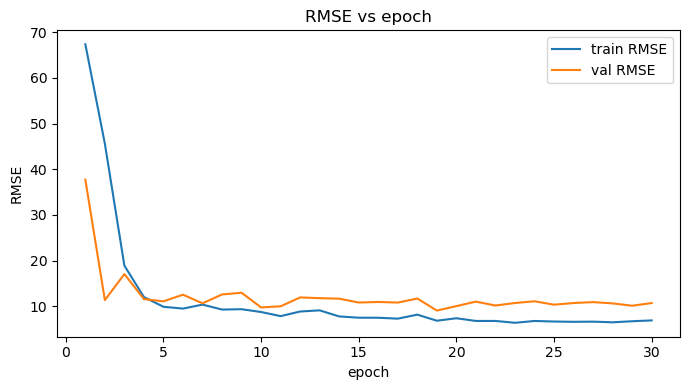

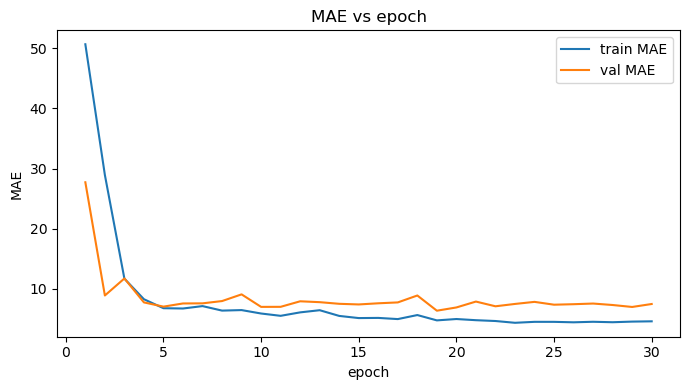

In [265]:
# plotting training curves
plt.figure(figsize=(7,4))
plt.plot(hist["ep"], hist["tr_rmse"], label="train RMSE")
plt.plot(hist["ep"], hist["va_rmse"], label="val RMSE")
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.title("RMSE vs epoch")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist["ep"], hist["tr_mae"], label="train MAE")
plt.plot(hist["ep"], hist["va_mae"], label="val MAE")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.title("MAE vs epoch")
plt.legend()
plt.tight_layout()
plt.show()


FD001 Test  | RMSE: 24.36 | MAE: 15.49


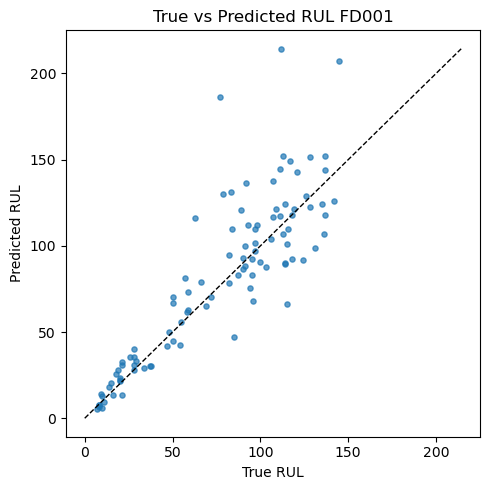

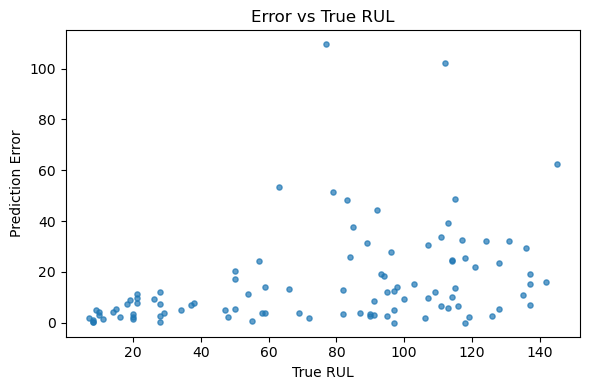

In [266]:
# Test evaluation
te_loss, te_rmse, te_mae = epoch_pass(model, te_ld, train=False)
print(f"\nFD001 Test  | RMSE: {te_rmse:.2f} | MAE: {te_mae:.2f}")

# prediction scatter plot
model.eval()
with torch.no_grad():
    yhat_list = []
    for xb, yb in te_ld:
        yhat_list.append(model(xb.to(dev)).cpu().numpy())
yhat = np.concatenate(yhat_list).ravel()

plt.figure(figsize=(5,5))
plt.scatter(ytest, yhat, s=14, alpha=0.7)
mx = max(ytest.max(), yhat.max())
plt.plot([0,mx],[0,mx],'k--',lw=1)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL FD001")
plt.tight_layout()
plt.show()

# Error vs true RUL
err = yhat - ytest
plt.figure(figsize=(6,4))
plt.scatter(ytest, np.abs(err), s=14, alpha=0.7)
plt.xlabel("True RUL")
plt.ylabel("Prediction Error")
plt.title("Error vs True RUL")
plt.tight_layout()
plt.show()

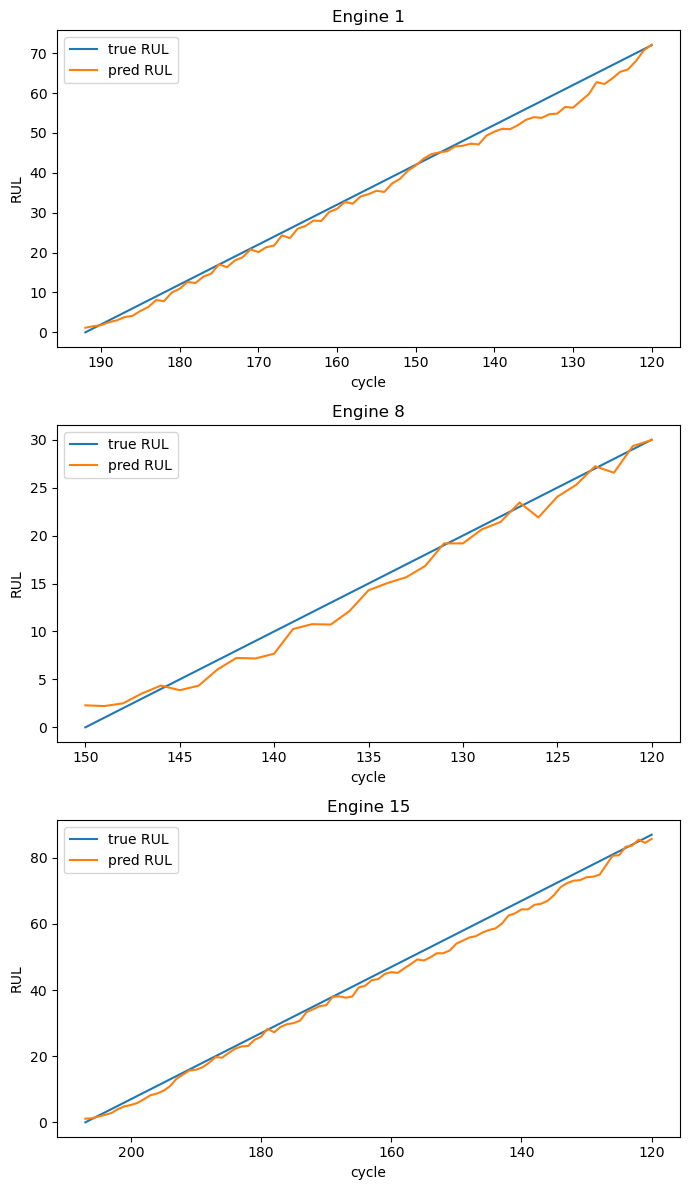

In [267]:
# Trajectory for couple training engines
def plot_engine_trajectories(rec: np.ndarray, engines: list, w: int, model: nn.Module, n_show=3):
    """
    plots predicted RUL vs true RUL over time for selected engines
    """
    
    model.eval()
    engines = engines[:n_show]
    plt.figure(figsize=(7, 4*len(engines)))
    for k, e in enumerate(engines, 1):
        rows = rec[rec[:,0].astype(int)==e]
        feats = rows[:,2:]
        t_e = rows[:,1].astype(int)
        t_last = t_e.max()
        true_rul = t_last - t_e
        X_e, y_e = windows_from_engine(rows, w)
        X_e = np.transpose(X_e, (0,2,1))
        with torch.no_grad():
            yh = model(torch.from_numpy(X_e).float().to(dev)).cpu().numpy().ravel()
        # align prediction times (start at w-1)
        tt = t_e[w-1:]
        plt.subplot(len(engines),1,k)
        plt.plot(tt, true_rul[w-1:], label="true RUL")
        plt.plot(tt, yh, label="pred RUL")
        plt.gca().invert_xaxis()  # for decreasing cycles remaining
        plt.xlabel("cycle"); plt.ylabel("RUL")
        plt.title(f"Engine {e}")
        plt.legend()
    plt.tight_layout(); plt.show()

# pick train engines to visualize
some_eng = [1, 8, 15, 36]
plot_engine_trajectories(train_rec, some_eng, w=w_size, model=model, n_show=3)

In [268]:
def precision_at_k(y_true, y_pred, k=20):
    """
    Precision@k for regression
    Returns the % of predictions within ±k cycles
    """
    err = np.abs(y_pred - y_true)
    return np.mean(err <= k)
precision10 = precision_at_k(ytest, yhat, k=10)
precision20 = precision_at_k(ytest, yhat, k=20)
precision30 = precision_at_k(ytest, yhat, k=30)
precision40 = precision_at_k(ytest, yhat, k=40)
precision50 = precision_at_k(ytest, yhat, k=50)

print ("Precision at k cycles:\n")
print(f"Precision@10: {precision10*100:.1f}%")
print(f"Precision@20: {precision20*100:.1f}%")
print(f"Precision@30: {precision30*100:.1f}%")
print(f"Precision@40: {precision40*100:.1f}%")
print(f"Precision@50: {precision50*100:.1f}%")

Precision at k cycles:

Precision@10: 54.0%
Precision@20: 74.0%
Precision@30: 84.0%
Precision@40: 92.0%
Precision@50: 95.0%


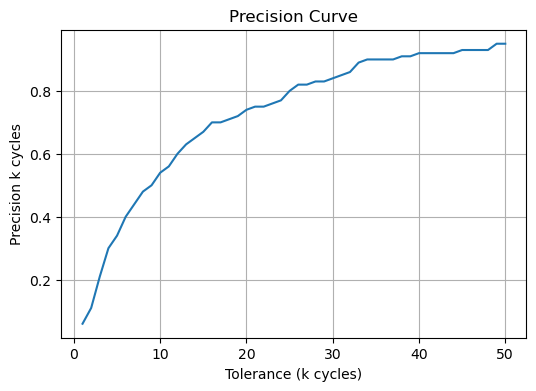

In [270]:
ks = range(1,51)
precisions = [precision_at_k(ytest, yhat, k) for k in ks]

plt.figure(figsize=(6,4))
plt.plot(ks, precisions)
plt.xlabel("Tolerance (k cycles)")
plt.ylabel("Precision k cycles")
plt.title("Precision Curve")
plt.grid(True)
plt.show()

In [173]:
print(os.getcwd())

C:\Users\AORUS\anaconda3\envs\work\Deep Learning\Final proy
